Generating 1000 simulations...
  Simulation 50...
  Simulation 100...
  Simulation 150...
  Simulation 200...
  Simulation 250...
  Simulation 300...
  Simulation 350...
  Simulation 400...
  Simulation 450...
  Simulation 500...
  Simulation 550...
  Simulation 600...
  Simulation 650...
  Simulation 700...
  Simulation 750...
  Simulation 800...
  Simulation 850...
  Simulation 900...
  Simulation 950...
  Simulation 1000...

Starting model training...
Epoch [10/300], Val Loss: 1.047269
Epoch [20/300], Val Loss: 0.237028
Epoch [30/300], Val Loss: 0.069134
Epoch [40/300], Val Loss: 0.054617
Epoch [50/300], Val Loss: 0.051724
Epoch [60/300], Val Loss: 0.053467
Epoch [70/300], Val Loss: 0.051396
Epoch [80/300], Val Loss: 0.050914
Epoch [90/300], Val Loss: 0.052690
Epoch [100/300], Val Loss: 0.051795
Epoch [110/300], Val Loss: 0.050179
Early stopping at epoch 118


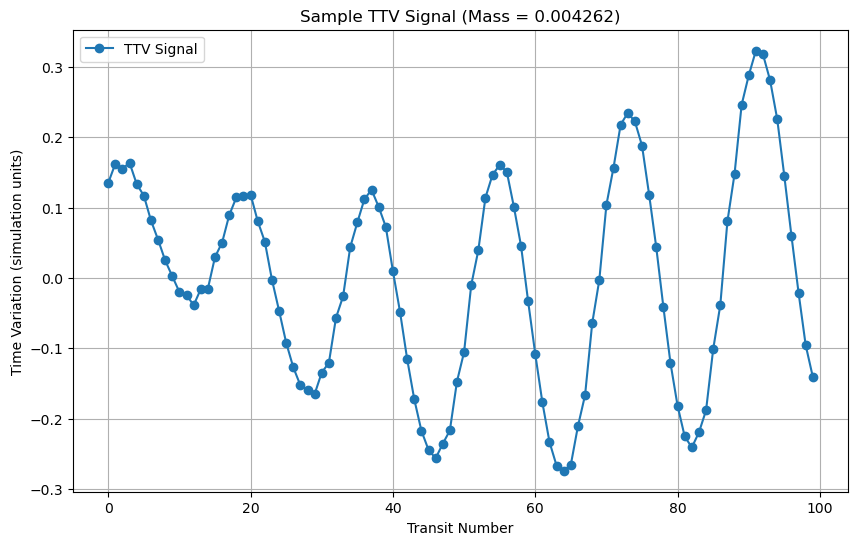

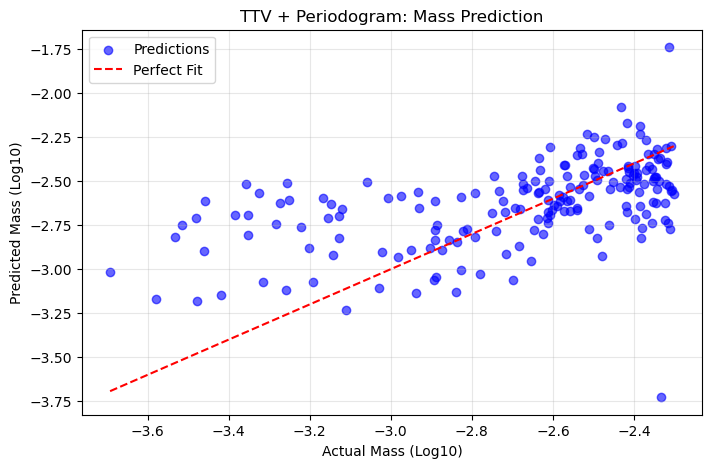


Amplitude-to-Mass Correlation: 0.1910

Model saved to ttv_mass_predictor.pth
Scaler saved to X_scaler.pkl


In [5]:
import numpy as np
import rebound
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from astropy.timeseries import LombScargle
from scipy.stats import pearsonr
import joblib

#-----------------------------------------------------------------------------
# Script Variables
#-----------------------------------------------------------------------------
NUM_SIMULATIONS = 1000
MAX_TRANSITS = 100
USE_RESONANCES = True
#-----------------------------------------------------------------------------
# Utility Functions
#-----------------------------------------------------------------------------

def detect_transits(sim, integration_time, dt, max_transits, planet_index):
    transit_times = []
    star = sim.particles[0]             # star is always the first element in our sim (or should be!)
    planet = sim.particles[planet_index]# specify the index of the planet in our sim whose transits we want to detect
    prev_y = planet.y - star.y
    
    time = 0
    while time < integration_time and len(transit_times) < max_transits:
        sim.integrate(sim.t + dt)           # progress simulation
        time = sim.t                        # get time from sim
        curr_y = planet.y - star.y          
        # if the product of previous and current y is negative, they they are on 
        # opposite sides of the y axis, and so there has been a transit of the y-axis
        # if (planet.x - star.x) > 0, then the planet is in front of the star: transit occured
        if prev_y * curr_y < 0 and (planet.x - star.x) > 0:
            # perform linear interpolation to find more precise moment of crossing
            weight = -prev_y / (curr_y - prev_y)
            precise_time = (time - dt) + (weight * dt)
            transit_times.append(precise_time)
        prev_y = curr_y
    return np.array(transit_times)

def detrend_ttv(ttv_data):
    """
    Remove the linear trend from a single TTV array
    
    Inputs:
        array: ttv data
    Outputs:
        array: detrended ttv data
    """
    N = len(ttv_data)                                   # get length of input
    transit_numbers = np.arange(N)                      # create array of transit numbers
    P = np.polyfit(transit_numbers, ttv_data, 1)        # fit straight line to ttv data
    return ttv_data - (P[0] * transit_numbers + P[1])   # subtract line from ttv and return

#-----------------------------------------------------------------------------
# PHASE 1: GENERATE DATA WITH PERIODOGRAM
#-----------------------------------------------------------------------------

def generate_simulation_data(num_simulations, max_transits):
    """
    Generate the simulation data to train our model
    
    :param num_simulations: number of simulations to be run
    :param max_transits: number of transits to reach before terminating a sim
    """
    print(f"Generating {num_simulations} simulations...")
    all_features = []
    all_masses = []
    all_ttvs = []
    
    # Use strong resonances to ensure a learnable signal
    resonances = [1.5, 2.0, 3.0] # [1.25, 1.333, 1.5, 2.0, 3.0]# 
    
    for i in range(num_simulations):
        if (i + 1) % 50 == 0: print(f"  Simulation {i+1}...")
        
        try:
            # Randomize Planet B
            m_b = np.random.uniform(1e-5, 1e-4) # mass
            P_b = np.random.uniform(2*np.pi, 4*np.pi)   # period
            e_b = np.random.uniform(0.0, 0.02)  # eccentricity
            
            # Randomize Planet C (The Perturber)
            # define if setting period ratio from resonance array or set range
            if USE_RESONANCES:
                ratio = np.random.choice(resonances) + np.random.uniform(-0.07, 0.07) # ratio of period to planet B
            else:
                ratio = np.random.uniform(1.25, 2.5)#
            m_c = np.random.uniform(1e-4, 5e-3) # mass
            P_c = P_b * ratio                   # period
            e_c = np.random.uniform(0.0, 0.05)  # eccentricity

            dt = P_b / 50   # time step to be used by integrators

            # Unperturbed Simulation
            sim_u = rebound.Simulation()    # create simulation                             
            sim_u.integrator = "whfast";    # specify the integrator                        
            sim_u.dt = dt                   # set time step of integrator                   
            sim_u.add(m=1.0);               # add 1 solar mass star to sim                  
            sim_u.add(m=m_b, P=P_b, e=e_b)  # add planet B to sim                           
            sim_u.move_to_com()             # set centre of mass of system as the origin
            transits_u = detect_transits(   # in unperturbed sim, find transits of planet B
                sim_u,                  # simulation to use
                P_b*(max_transits+5),   # integration time 
                dt,                     # integrator time step 
                max_transits,           # max number of transits we're looking for  
                1                       # index of transiting planet in simulation  
            )   

            # Perturbed Simulation  
            sim_p = rebound.Simulation()    # create simulation                            
            sim_p.integrator = "whfast";    # specify the integrator                       
            sim_p.dt = dt                   # set time step of integrator                  
            sim_p.add(m=1.0);               # add 1 solar mass star to sim                 
            sim_p.add(m=m_b, P=P_b, e=e_b)  # add planet B to sim                          
            sim_p.add(m=m_c, P=P_c, e=e_c)  # in unperturbed sim, find transits of planet B
            sim_p.move_to_com()             # set centre of mass of system as the origin
            transits_p = detect_transits(
                sim_p,                  # simulation to use
                P_b*(max_transits+5),   # integration time
                dt,                     # integrator time step
                max_transits,           # max number of transits we're looking for  
                1                       # index of transiting planet in simulation
            )

            # proceed if we have a sufficient number of transits in both simulations
            if len(transits_u) >= max_transits and len(transits_p) >= max_transits:
                ttv_vec = detrend_ttv(transits_p[:max_transits] - transits_u[:max_transits])
                
                # Convert TTV wiggles into a frequency spectrum to identify the dominant
                # orbital resonance frequency between the planets.
                # Search for cycles between 3 transits and 50 transits, with 40 sample bins
                freqs = np.linspace(1/50, 1/3, 40)
                power = LombScargle(np.arange(max_transits), ttv_vec).power(freqs)
                
                # Feature Construction: [Amplitude, Power Spectrum, Phys Params]
                amp = np.std(ttv_vec)
                phys = [P_b, ratio, e_b]
                
                features = np.hstack(([amp], power, phys)) # stack our features
                all_features.append(features)
                all_masses.append(m_c)
                all_ttvs.append(ttv_vec)


        except Exception: continue

    return np.array(all_features), np.array(all_masses), np.array(all_ttvs)

#-----------------------------------------------------------------------------
# PHASE 2: MASS PREDICTOR MODEL
#-----------------------------------------------------------------------------

class MassPredictor(nn.Module):
    def __init__(self, input_size):
        super(MassPredictor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)

def train_model(model, X_train, y_train, X_val, y_val, epochs=200, batch_size=16):           
    print("\nStarting model training...")
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    criterion = nn.HuberLoss()                                                                            
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3) 
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

    best_val_loss, patience_counter, max_patience = float('inf'), 0, 30
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        indices = torch.randperm(len(X_train_t)) # PREVENTS LEARNING ANY KIND OF ORDER
        for i in range(0, len(X_train_t), batch_size):
            batch_indices = indices[i:i+batch_size]
            batch_X, batch_y = X_train_t[batch_indices], y_train_t[batch_indices]
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            optimizer.zero_grad()
            loss.backward() # Backpropagation uses calculus chain rule
            optimizer.step() # Weights update
            train_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t)
        
        scheduler.step(val_loss)
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Val Loss: {val_loss.item():.6f}')
        
        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            if patience_counter >= max_patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    return model

#-----------------------------------------------------------------------------
# PHASE 3: TRAINING AND EVALUATION
#-----------------------------------------------------------------------------

if __name__ == "__main__":
    X_raw, y_raw, ttvs = generate_simulation_data(NUM_SIMULATIONS, MAX_TRANSITS)
    
    # Log Scaling for Mass (converts tiny decimals to manageable numbers like -1 to -4)
    y_log = np.log10(y_raw)
    
    # Preprocessing
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X_raw)
    
    # Data Splitting: Train (64%), Val (16%), Test (20%)
    X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y_log, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
    
    # Initialize and Train
    model = MassPredictor(X_train.shape[1])
    model = train_model(model, X_train, y_train, X_val, y_val, epochs=300)

    # Results
    model.eval()
    with torch.no_grad():
        test_preds = model(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()
    
    # Plotting
    # 5. Visualize sample TTV signal
    plt.figure(figsize=(10, 6))
    plt.plot(ttvs[0], 'o-', label='TTV Signal')
    plt.title(f'Sample TTV Signal (Mass = {y_raw[0]:.6f})')
    plt.xlabel('Transit Number')
    plt.ylabel('Time Variation (simulation units)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # predicted mass vs actual
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, test_preds, alpha=0.6, color='blue', label='Predictions')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')
    plt.xlabel("Actual Mass (Log10)")
    plt.ylabel("Predicted Mass (Log10)")
    plt.title("TTV + Periodogram: Mass Prediction")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    corr, _ = pearsonr(X_raw[:, 0], y_raw)
    print(f"\nAmplitude-to-Mass Correlation: {corr:.4f}")



    ##############################
    # --- SAVE THE MODEL ---
    # Define a filename
    model_filename = "ttv_mass_predictor.pth"
    
    # Save the weights and the scaler (you need the scaler to process future data!)
    
    torch.save(model.state_dict(), model_filename)
    joblib.dump(scaler_X, "X_scaler.pkl") 
    
    print(f"\nModel saved to {model_filename}")
    print("Scaler saved to X_scaler.pkl")

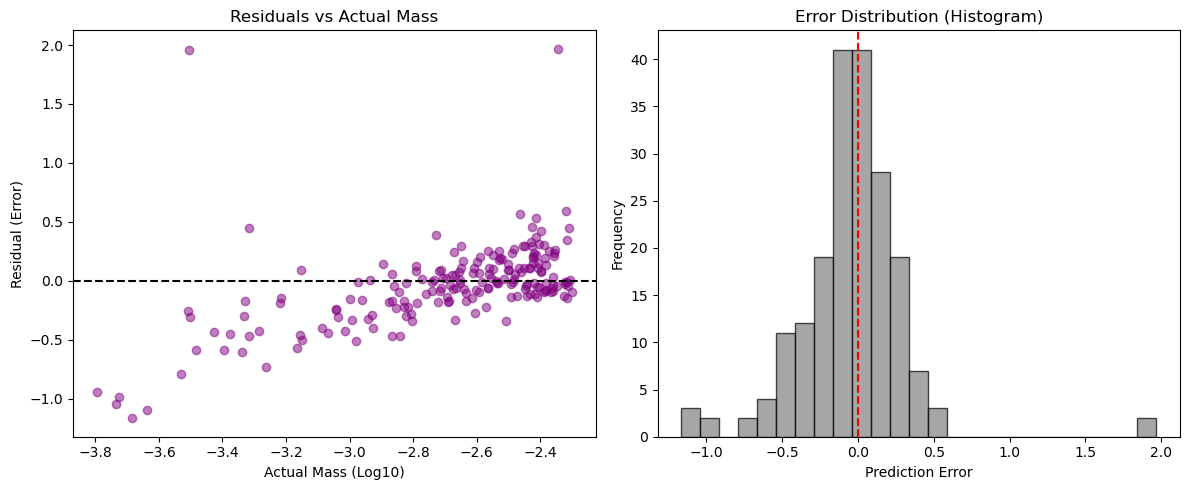

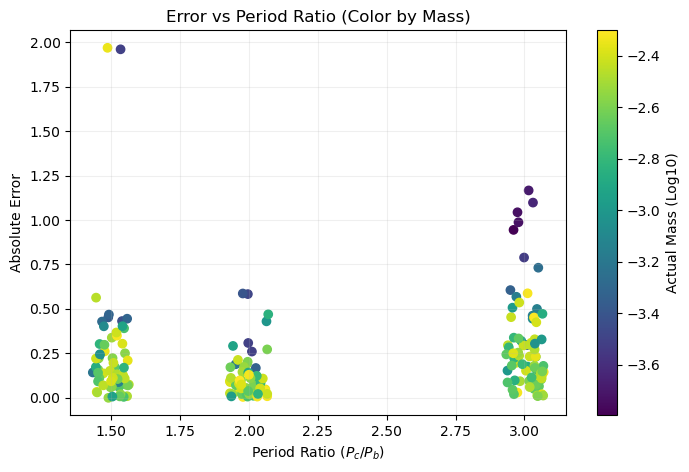


--- Statistical Error Analysis ---
Mean Absolute Error: 0.2302 dex
Root Mean Squared Error: 0.3579 dex
Typical Error: Factor of 1.70x in mass


In [4]:
# --- ERROR ANALYSIS ---
residuals = y_test - test_preds

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Actual Mass
plt.subplot(1, 2, 1)
plt.scatter(y_test, residuals, alpha=0.5, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Actual Mass (Log10)")
plt.ylabel("Residual (Error)")
plt.title("Residuals vs Actual Mass")

# Plot 2: Error Distribution
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=25, color='gray', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Histogram)")
plt.tight_layout()
plt.show()


# Get the indices of the test set from the original data
# (Assuming you didn't shuffle indices manually, we can find them via y_test matches)
test_indices = []
for val in y_test:
    idx = np.where(y_log == val)[0][0]
    test_indices.append(idx)

test_ratios = X_raw[test_indices, -2]  # 'ratio' was the 2nd to last feature

plt.figure(figsize=(8, 5))
plt.scatter(test_ratios, np.abs(residuals), c=y_test, cmap='viridis')
plt.colorbar(label='Actual Mass (Log10)')
plt.xlabel("Period Ratio ($P_c / P_b$)")
plt.ylabel("Absolute Error")
plt.title("Error vs Period Ratio (Color by Mass)")
plt.grid(True, alpha=0.2)
plt.show()

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, test_preds)
rmse = np.sqrt(mean_squared_error(y_test, test_preds))

print(f"\n--- Statistical Error Analysis ---")
print(f"Mean Absolute Error: {mae:.4f} dex") 
print(f"Root Mean Squared Error: {rmse:.4f} dex")
print(f"Typical Error: Factor of {10**mae:.2f}x in mass")